In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess

# Non-stationary time series (trend)
## Simulate a non-stationary AR(2) process with a trend

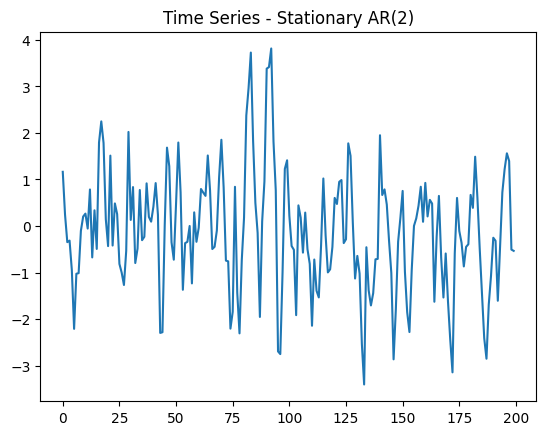

In [ ]:
np.random.seed(6211)
n = 200
# AR(2) parameters
ar = np.array([1, -0.75, 0.25]) # Coefficients for autoregressive lag polynomial, including zero lag.
ma = np.array([1]) # Coefficient for moving-average lag polynomial, including zero lag.
ar_process = ArmaProcess(ar, ma)


data = ar_process.generate_sample(nsample=n)
plt.plot(data)
plt.title("Time Series - Stationary AR(2)")
plt.show()


## ADF (Augmented Dickey-Fuller) Test
Are this time series stationary?

In [ ]:
result = adfuller(data)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p > 0.05, it is non-stationary

ADF Statistic: -7.96314239034467
p-value: 2.9121790461779955e-12


If there is a trend in time series, no constant mean!

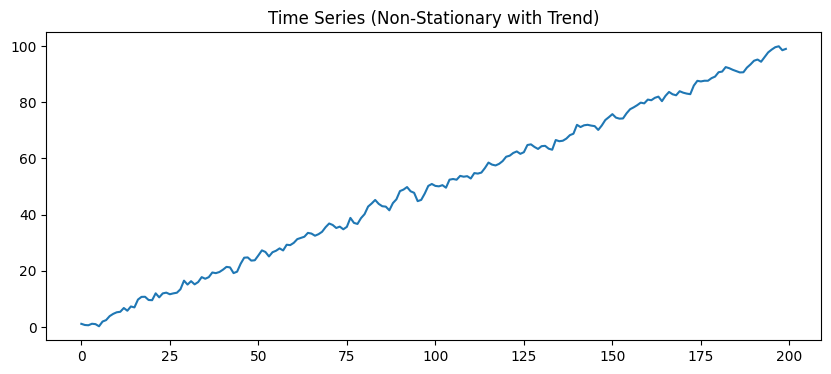

In [ ]:
# Add a trend to make it non-stationary
time_index = np.arange(n)
trend_data = data + 0.5 * time_index

# 2. Plot the original non-stationary data
plt.figure(figsize=(10, 4))
plt.plot(trend_data)
plt.title("Time Series (Non-Stationary with Trend)")
plt.show()

Stationary?  Check with ADF.

In [ ]:
result = adfuller(trend_data)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p > 0.05, it is non-stationary

ADF Statistic: -0.20503864942737662
p-value: 0.9379183527748323


Also check ACF and PACF!

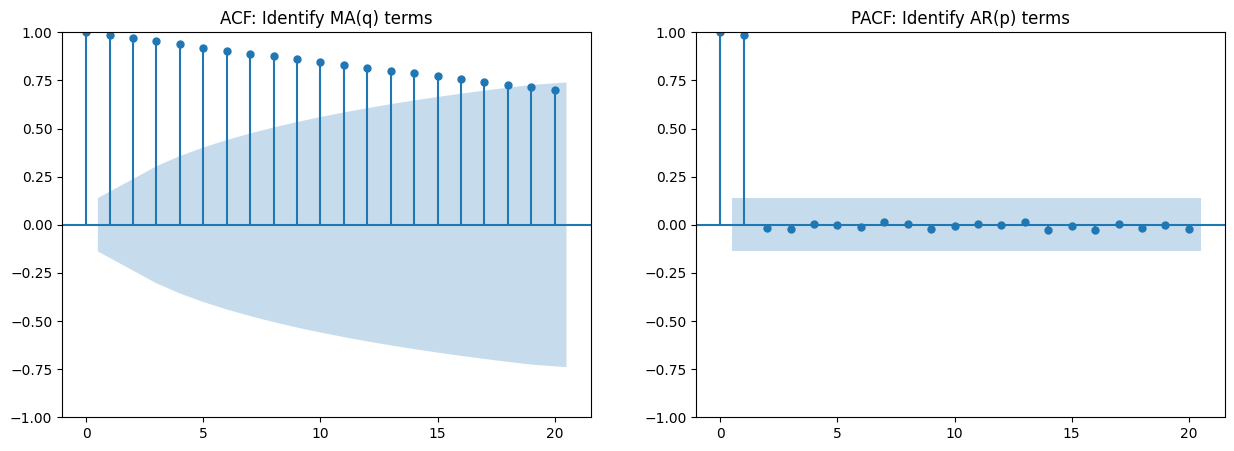

In [ ]:
# Generate ACF and PACF plots for the non-stationary series
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(trend_data, ax=ax[0], lags=20)
ax[0].set_title("ACF: Identify MA(q) terms")
plot_pacf(trend_data, ax=ax[1], lags=20)
ax[1].set_title("PACF: Identify AR(p) terms")
plt.show()

## Differencing works!
Applying first-order differencing...

In [ ]:
pd.Series(trend_data).diff().head() # First row will be NaN

,0
0,NaN
1,-0.420783
2,-0.090638
3,0.533132
4,-0.133867


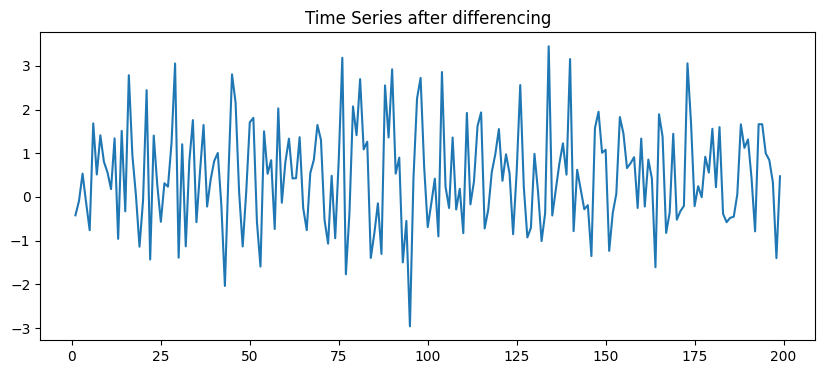

In [ ]:
differenced_data = pd.Series(trend_data).diff().dropna()
# Plot differenced_data
plt.figure(figsize=(10, 4))
plt.plot(differenced_data)
plt.title("Time Series after differencing")
plt.show()

In [ ]:
# Test for Stationarity using Augmented Dickey-Fuller
result_diff = adfuller(differenced_data)
print(f'ADF Statistic: {result_diff[0]}')
print(f'p-value: {result_diff[1]}') # If p > 0.05, it is non-stationary

ADF Statistic: -8.860118766534763
p-value: 1.4907395448085435e-14


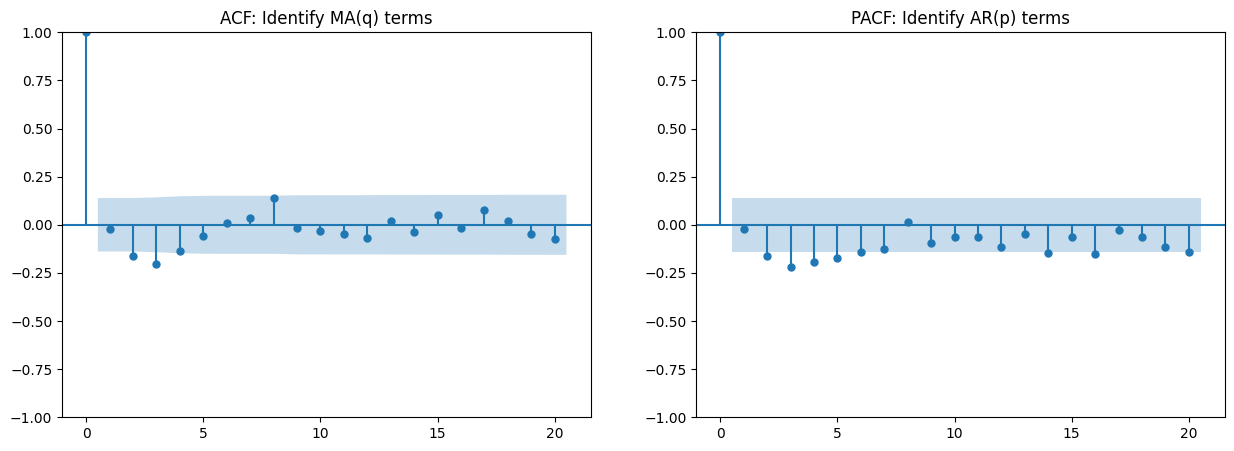

In [ ]:
# Generate ACF and PACF plots for the stationary series
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(differenced_data, ax=ax[0], lags=20)
ax[0].set_title("ACF: Identify MA(q) terms")
plot_pacf(differenced_data, ax=ax[1], lags=20)
ax[1].set_title("PACF: Identify AR(p) terms")
plt.show()

# Time series with seasonality
Generate SARIMA(0,0,2)(0,1,0)12 data

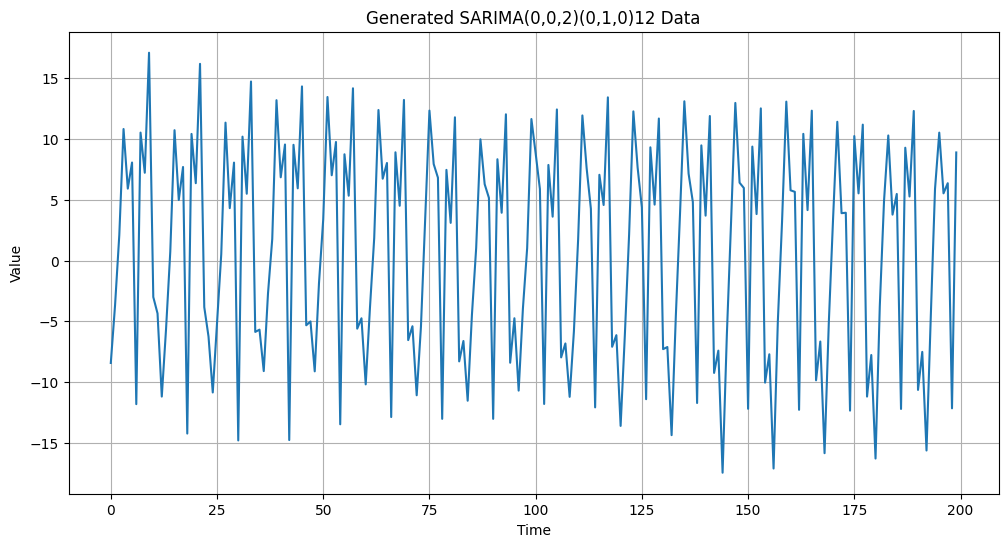

Generated SARIMA data shape: (200,)
First 5 values of generated SARIMA data: [-8.42151112 -3.68444156  2.10259948 10.81895994  5.91719415]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess

# SARIMA
# Non-seasonal MA(2): (1 + theta1*B + theta2*B^2)
# Seasonal Differencing (D=1, s=12): (1 - B^12)

n_samples = 200

# AR coefficients for the (1 - B^12) part
# In ArmaProcess, ar = [1, -phi_1, -phi_2, ...]
# For (1 - B^12), it means phi_12 = 1, others 0.
# So, ar_coeffs should be [1, 0, ..., 0, -1] where -1 is at index 12.
ar_coeffs = np.zeros(13)
ar_coeffs[0] = 1
ar_coeffs[12] = -1

# MA coefficients for the (1 + theta1*B + theta2*B^2) part
# In ArmaProcess, ma = [1, theta_1, theta_2, ...]
# Let's choose arbitrary values for theta1 and theta2, e.g., 0.5 and 0.3
ma_coeffs = np.array([1, 0.5, 0.3])

# Create the ArmaProcess model
sarima_process = ArmaProcess(ar_coeffs, ma_coeffs)

# Generate SARIMA data with a burn-in period to stabilize the series
sarima_data = sarima_process.generate_sample(nsample=n_samples, burnin=500)

# Plot the generated data
plt.figure(figsize=(12, 6))
plt.plot(sarima_data)
plt.title("Generated SARIMA(0,0,2)(0,1,0)12 Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

print("Generated SARIMA data shape:", sarima_data.shape)
print("First 5 values of generated SARIMA data:", sarima_data[:5])

In [ ]:
# Test for Stationarity using Augmented Dickey-Fuller
result = adfuller(sarima_data)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p > 0.05, it is non-stationary

ADF Statistic: -1.152356227583776
p-value: 0.6937480246051158


In [ ]:
# Differenced SARIMA data
sarima_data_diff = pd.Series(sarima_data).diff(12).dropna()
sarima_data_diff

,0
12,-2.763073
13,-1.964804
14,-1.370015
15,-0.097562
16,-0.934884
...,...
195,0.233424
196,1.748790
197,0.886414
198,0.050787


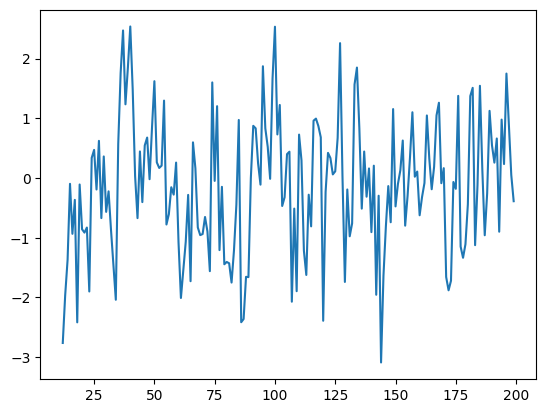

In [ ]:
plt.plot(sarima_data_diff)

In [ ]:
# Test for Stationarity using Augmented Dickey-Fuller
result = adfuller(sarima_data_diff)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p > 0.05, it is non-stationary

ADF Statistic: -9.082392483571931
p-value: 4.023423877129263e-15
